In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

SEED = 12

# Parte 2: Modelos de Mezcla

Para esta parte se utilizó el dataset pizza_sales.csv, que contiene la información de ventas de pizzas.

Buscamos identificar distintos tipos de días según la cantidad de pedidos, por ejemplo días tranquilos y días muy ajetreados. Cada componente del modelo describe un tipo de día con su propia tasa media de pedidos.

In [2]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [3]:
pizza.describe()

,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000
mean,10701.479761,1.019622,16.494132,16.821474
std,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,9.750000,9.750000
25%,5337.000000,1.000000,12.750000,12.750000
50%,10682.500000,1.000000,16.500000,16.500000
75%,16100.000000,1.000000,20.250000,20.500000
max,21350.000000,4.000000,35.950000,83.000000


Al iniciar el análisis exploratorio, se observó que el dataset cuenta con 48.620 registros de ventas. La mayoría de los pedidos incluyen una sola pizza (`quantity` ≈ 1), con precios unitarios promedio cercanos a 16,5 y un máximo de 35,95. El precio total promedio (`total_price`) es de 16,8, aunque algunos pedidos alcanzan valores más altos al incluir varias pizzas o variedades de mayor costo.

Estos datos tienen una estructura de conteo, vamos a modelar las ventas por fecha.

In [4]:
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

In [5]:
conteo = pizza.groupby(['order_date']).size().reset_index(name='n_orders')
conteo

,order_date,n_orders
0,2015-01-01,161
1,2015-01-02,160
2,2015-01-03,154
3,2015-01-04,106
4,2015-01-05,121
...,...,...
353,2015-12-27,87
354,2015-12-28,102
355,2015-12-29,77
356,2015-12-30,73


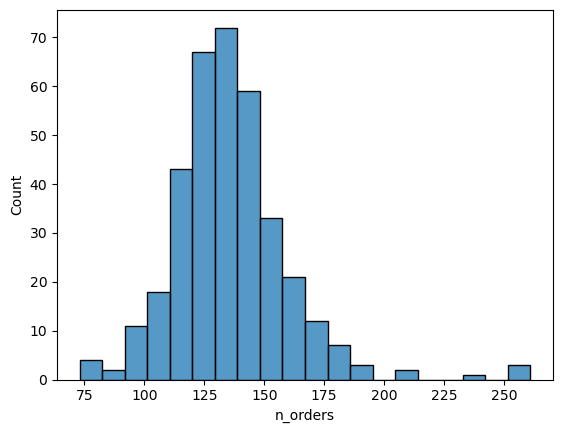

In [6]:
sns.histplot(conteo['n_orders'], bins=20);

Se observa que la mayoría de los días tienen entre 120 y 150 pedidos de pizza. La distribución es bastante concentrada alrededor de ese rango y cae rápidamente hacia los extremos, con pocos días de muy alta o muy baja cantidad de pedidos.

In [7]:
obs = conteo['n_orders'].values

In [8]:
obs.var(), obs.mean()

(np.float64(577.2991167566555), np.float64(135.81005586592178))

Los datos presentan sobre-dispersion (media $\approx 136$, varianza $\approx 577$). Esto justifica alejarse de una Poisson simple. Una alternativa natural es la Negative Binomial, que modela la varianza extra y es equivalente marginalmente a una mezcla Poisson–Gamma. Sin embargo, se propone un modelo de mezcla de Poisson porque puede explicar la variabilidad a través de subpoblaciones latentes (componentes) y facilitar la interpretación por grupos.

## 1.
Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o más normales) y justificar la elección.

Para empezar se buscan los dos grupos mencionados (días tranquilos y ajetreados). Para eso se plantea un modelo con dos componentes y con la siguiente estructura:

\begin{align}
\mu_k \sim \text{Gamma}(\mu_{\mu}, \sigma_{\mu}), k = 1, 2\\
w \sim \text{Dirichlet}(\alpha)\\
x_i | z_i \sim \text{Poisson}(\mu_{z_i})\\
z_i \sim \text{Categorical}(w)\\
\end{align}

Donde:
+ $\mu_k$ es la tasa media de pedidos del tipo de día $k$
+ $w = (w_1, w_2)$ son los pesos de mezcla, que representan la proporción esperada de cada $k$.
+ $z_i$ es la variable latente que indica a qué grupo pertenece el día $i$.
+ $x_i$ es la cantidad observada de ordenes en el día $i$.

In [38]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=obs.mean(), sigma=25, shape=k)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 59 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


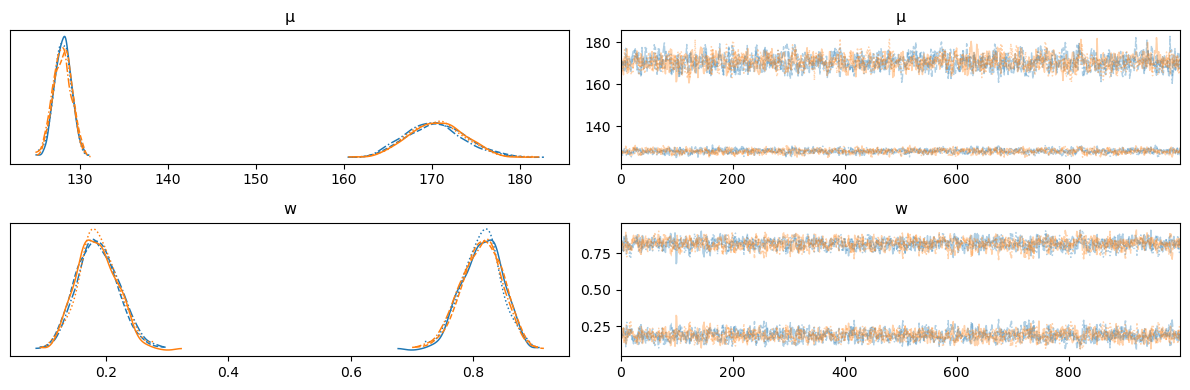

In [39]:
az.plot_trace(idata, var_names=['μ', 'w'])
plt.tight_layout();

Luego de analizar los gráficos, se observa que el modelo presenta problemas de identificabilidad, ya que los parámetros de los dos componentes se superponen y muestran simetría. En particular, las cadenas no convergen bien (la naranja se superpone con la azul y viceversa), lo que indica que el modelo no logra distinguir correctamente los grupos.

## 2.
Analizar la identificabilidad del modelo y discutir posibles problemas de simetría entre componentes.

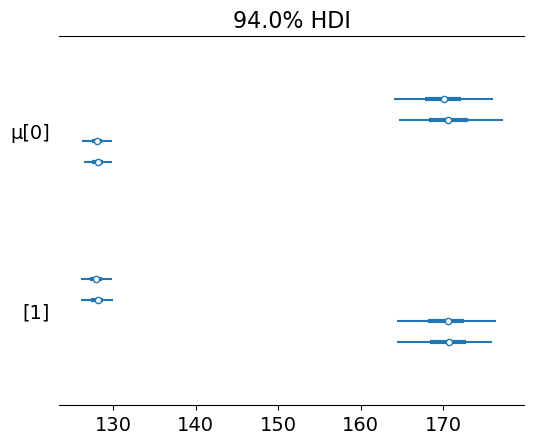

In [40]:
az.plot_forest(idata, var_names=['μ']);

El modelo presenta el problema de no identificabilidad de los componentes (_label sitching_), debido a que intercambiar los índices de las tasas $\mu_1$ y $\mu_2$ no altera la probabilidad de los datos.

Para resolverlo, se impuso una restricción de orden sobre los $\mu_k$, tal que:
$$
\mu_1 < \mu_2
$$

Esto rompe la simetría y evita el _label switching_.

También se eligen valores distintos de $\mu$ para cada componente, así obtenemos una forma consitente de elegir priors con distintos valores de $k$.

In [ ]:
k=2
μ_μ = np.quantile(obs, np.linspace(0.1, 0.9, k))
μ_μ

array([111., 161.])

In [ ]:
with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=μ_μ, sigma=25, shape=k, transform=pm.distributions.transforms.ordered)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.


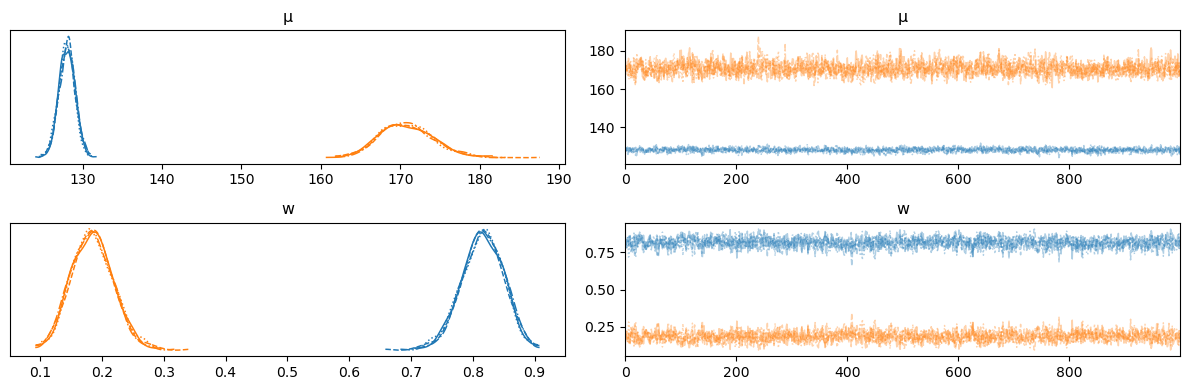

In [44]:
az.plot_trace(idata)
plt.tight_layout();

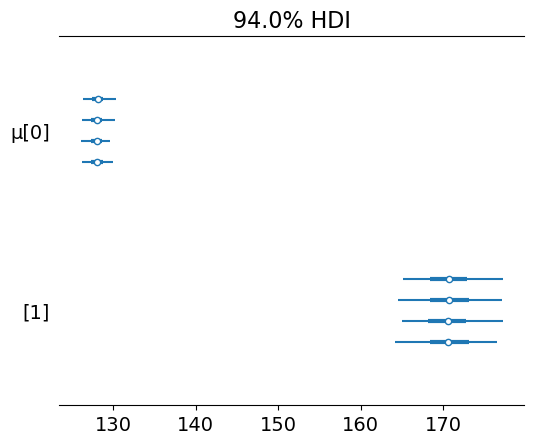

In [45]:
az.plot_forest(idata, var_names=['μ']);

In [46]:
az.summary(idata, kind="diagnostics")

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.022,0.014,2059.0,2367.0,1.0
μ[1],0.085,0.054,1556.0,2373.0,1.0
w[0],0.001,0.001,1527.0,2331.0,1.0
w[1],0.001,0.001,1527.0,2331.0,1.0


Los resultados muestran que el modelo se ajustó correctamente, ya que todos los valores de r_hat están por debajo del valor máximo recomendado (1.01), lo que indica una buena convergencia de las cadenas. Los tamaños efectivos de muestras esta bien por encima del valor mínimo recomendado (400, 100 por cadena).

## 3.
Comparar distintos valores de K (número de componentes) y evaluar cuál describe mejor los datos.

In [9]:
Ks = [2, 3, 4, 5, 6]

idatas = []
modelos = []

for k in Ks:
    μ_μ = np.quantile(obs, np.linspace(0, 1, k))
    
    with pm.Model() as poisson_mixture_model:
        μ = pm.Gamma('μ', mu=μ_μ, sigma=25, shape=k, transform=pm.distributions.transforms.ordered)
        w = pm.Dirichlet('w', a=np.ones(k))

        comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

        x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

        idata = pm.sample(target_accept=0.95, idata_kwargs={"log_likelihood": True}, random_seed=SEED)

        idatas.append(idata)
        modelos.append(poisson_mixture_model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 148 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 125 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 193 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 239 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 360 seconds.


c:\Users\nazar\anaconda3\envs\ei2\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


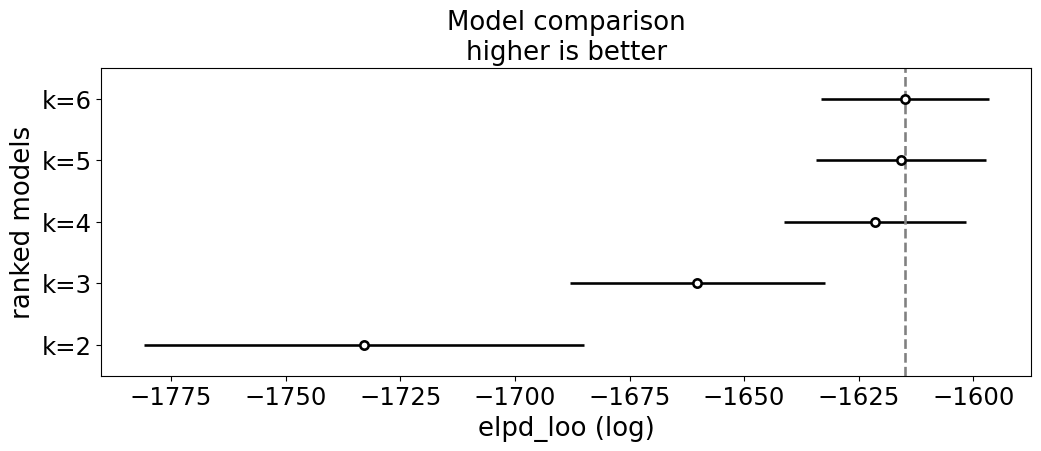

In [11]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
az.plot_compare(df_comp, figsize=(12, 4));

Se ajustaron modelos con $k = 2, 3, 4, 5, 6$ componentes, comparados mediante LOO.  
El mejor desempeño predictivo correspondió al modelo con $k=6$, seguido de cerca por el de $k=5$ y $k=4$. Sin embargo, la diferencia en el valor ``elpd_loo`` es menor que el error estándar (ver tabla), lo que indica que **no hay evidencia sólida de una mejora significativa al aumentar $k$.**

In [13]:
df_comp[['elpd_diff', 'se']]

,elpd_diff,se
k=6,0.000000,18.337603
k=5,0.948140,18.542383
k=4,6.535626,19.857032
k=3,45.356694,27.802789
k=2,118.113228,47.987122


Dado que el objetivo del análisis es identificar distintos tipos de días según demanda, un modelo con 6 componentes resultaría **poco interpretable** (no tendría sentido definir 6 categorías de "tipo de día").

Por este motivo se seleccionó el modelo con 4 componentes, que ofrece un buen equilibrio entre capacidad predictiva e interpretabilidad, permitiendo diferenciar grupos de días significativamente distintos.

In [14]:
for i, k in enumerate(Ks):
    modelo = modelos[i]
    idata = idatas[i]
    pm.sample_posterior_predictive(idata, model=modelo, random_seed=SEED, extend_inferencedata=True, progressbar=False)

Sampling: [x]
Sampling: [x]
Sampling: [x]
Sampling: [x]
Sampling: [x]


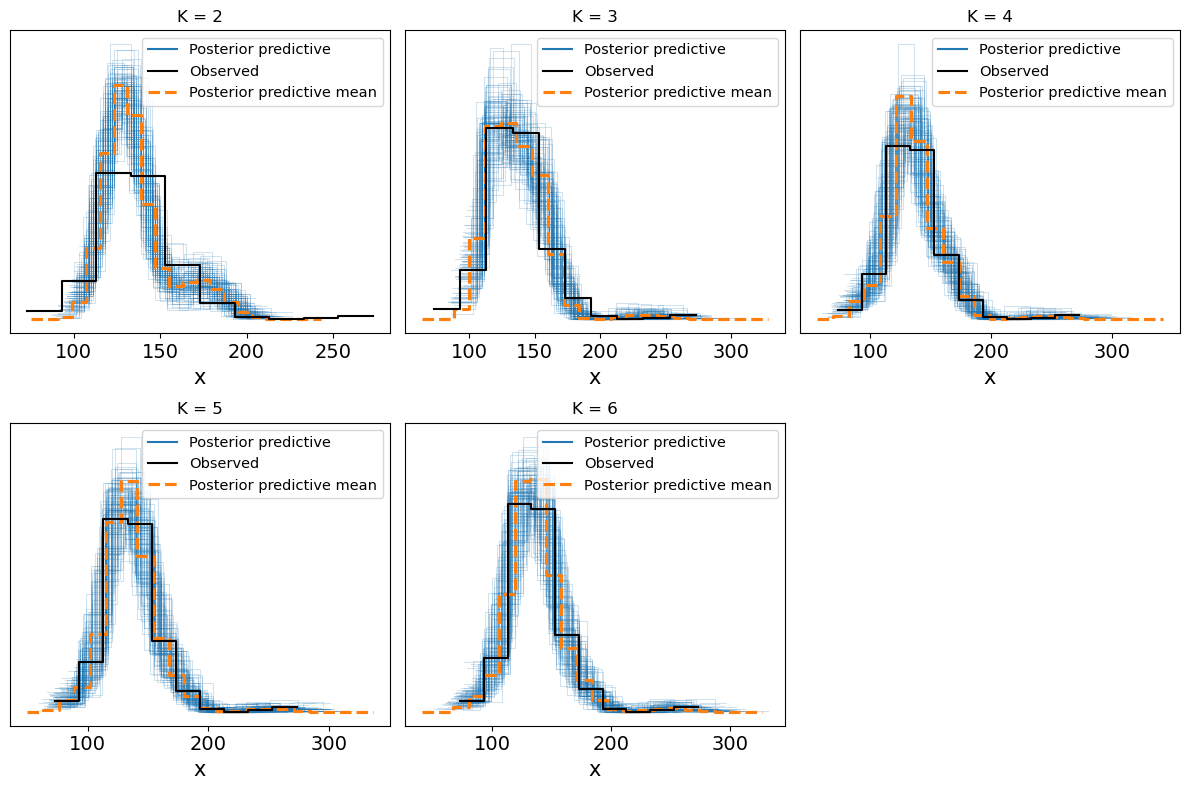

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = np.ravel(axes)
fig.delaxes(axes[-1])

for i, idata in enumerate(idatas):
    az.plot_ppc(idata, num_pp_samples=100, ax=axes[i])
    axes[i].set_title('K = {}'.format(Ks[i]))

plt.tight_layout();

Vemos que efectivamente las predicciones con k=4 no son muy distintas a k=5 o k=6

In [16]:
idata_k4 = idatas[2]

### Análisis de los grupos

#### Resultados generales

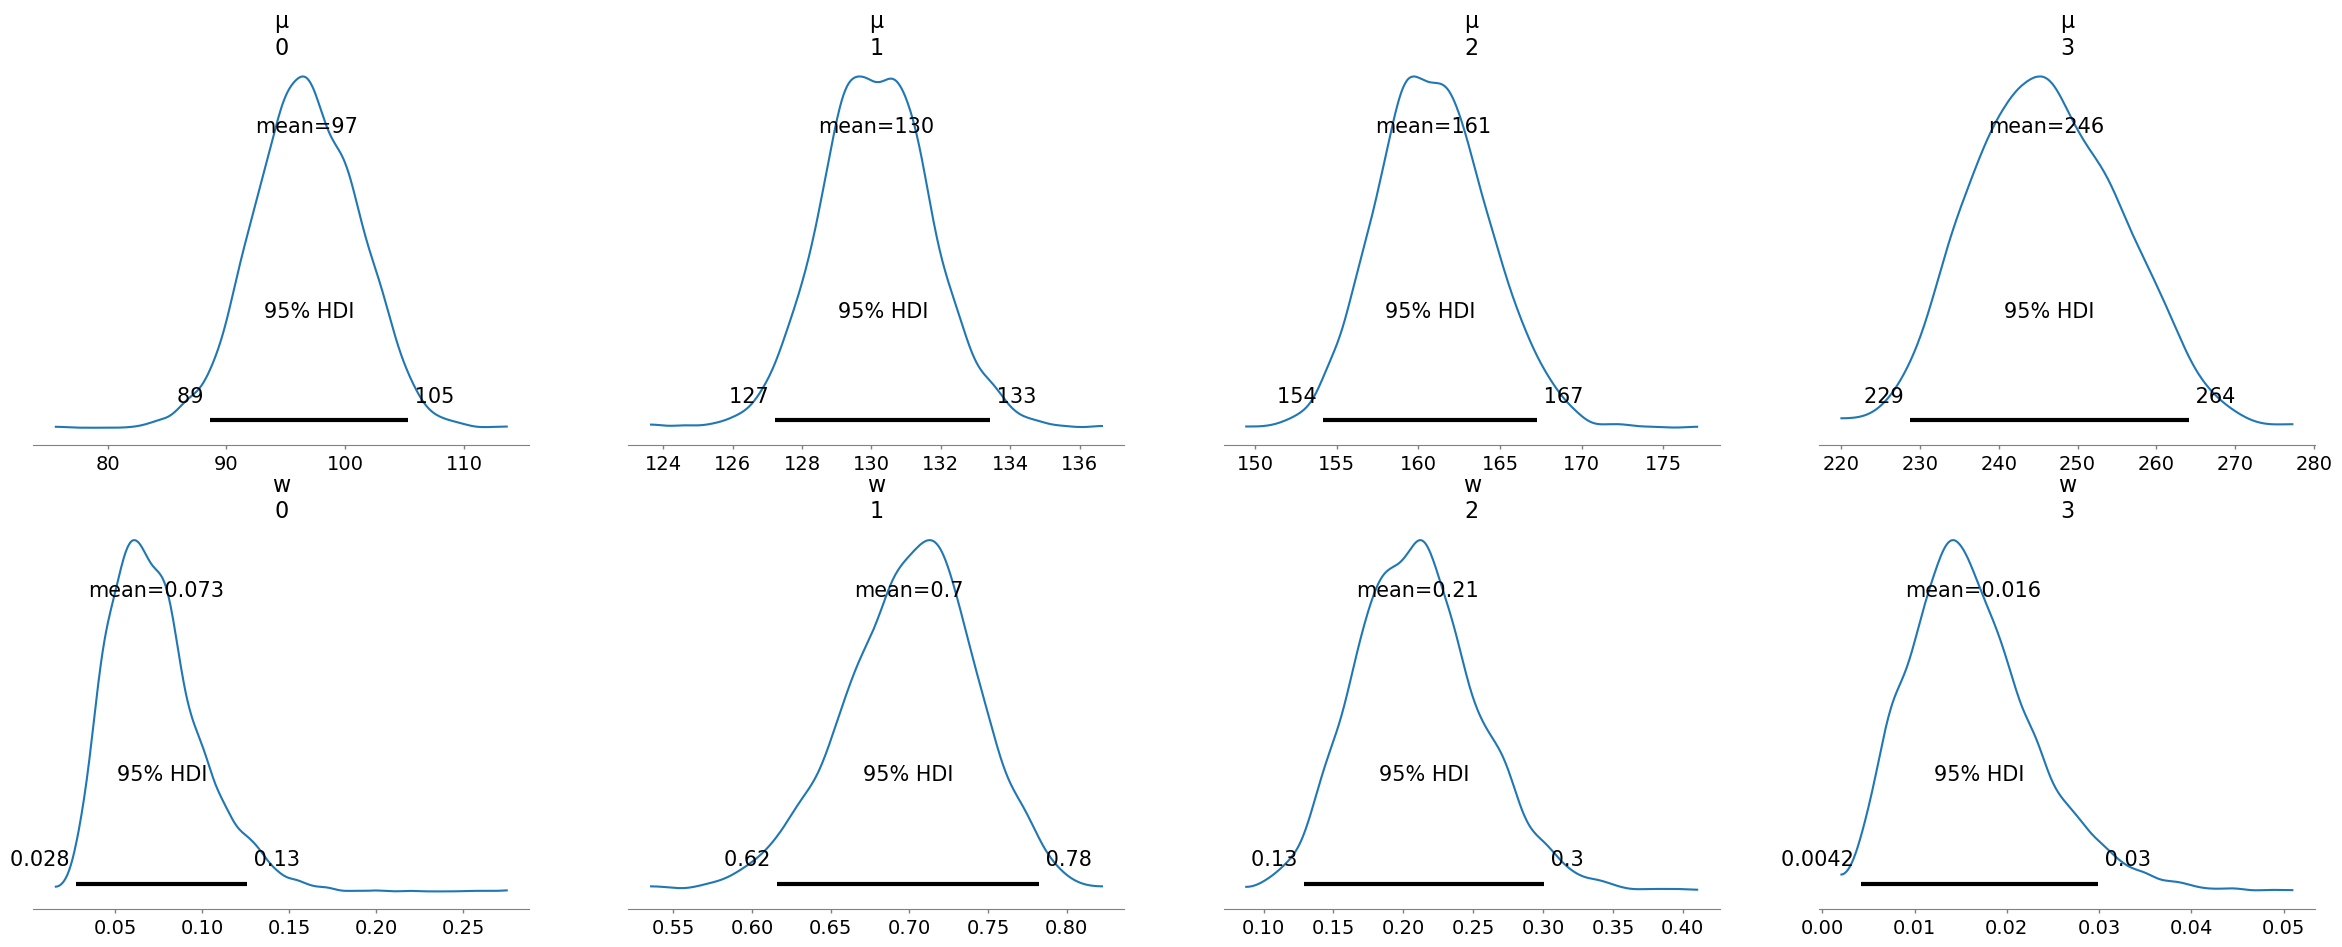

In [29]:
az.plot_posterior(idata_k4, var_names=['μ', 'w'], hdi_prob=0.95);

In [19]:
az.summary(idata_k4, hdi_prob=0.95, kind="stats")

,mean,sd,hdi_2.5%,hdi_97.5%
μ[0],96.706,4.349,88.636,105.294
μ[1],130.129,1.581,127.236,133.426
μ[2],160.923,3.397,154.178,167.244
μ[3],246.067,9.368,228.770,264.108
w[0],0.073,0.027,0.028,0.126
w[1],0.700,0.043,0.616,0.783
w[2],0.210,0.045,0.129,0.301
w[3],0.016,0.007,0.004,0.030


El modelo sugiere que la mayoría de los días ($\approx 70 \%$) pertenecen a un grupo de demanda "normal", con alrededor de $130$ pedidos.
Un segundo grupo ($\approx 21 \%$) corresponde a días de alta demanda ($\approx 160$ pedidos), y un grupo más pequeño ($\approx 7 \%$) muestra días con baja actividad ($\approx 97$ pedidos).
Por último, un grupo muy reducido ($\approx 1–2 \%$) agrupa días extraordinarios con una media cercana a $250$ pedidos, coincidiendo con fechas festivas.

#### Caracterización de los grupos

In [22]:
conteo['day_of_week'] = conteo['order_date'].dt.day_name()

##### Días de baja demanda ($\mu \approx 97$)
+ Proporción: $7 \%$ de los días.
+ Días más frecuentes: Domingo ($65 \%$ de los casos), seguido por Lunes y Martes.
+ Interpretación: corresponde a días de poca actividad, posiblemente asociados a cierre parcial, baja afluencia o posfin de semana.

In [23]:
conteo.query('n_orders <= 105').day_of_week.value_counts(normalize=True)

day_of_week
Sunday       0.652174
Tuesday      0.130435
Monday       0.086957
Wednesday    0.086957
Saturday     0.043478
Name: proportion, dtype: float64

##### Días típicos ($\mu \approx 130$)

+ Proporción: $70\%$ de los días.
+ Días más frecuentes: Miércoles, Martes, Lunes y Jueves.
+ Interpretación: representan la operativa normal de la pizzería.  

In [24]:
conteo.query('n_orders >= 127 & n_orders <= 134').day_of_week.value_counts(normalize=True)

day_of_week
Wednesday    0.283582
Tuesday      0.194030
Monday       0.179104
Thursday     0.149254
Saturday     0.089552
Sunday       0.074627
Friday       0.029851
Name: proportion, dtype: float64

##### Días de alta demanda ($\mu \approx 161$)

+ Proporción: $21\%$ de los días.
+ Días más frecuentes: viernes y sábado (más del $65\%$ de los casos).
+ Interpretación: son los días de fin de semana, donde el volumen de pedidos aumenta significativamente.

In [21]:
conteo.query('n_orders >=154 and n_orders <= 167').day_of_week.value_counts(normalize=True)

day_of_week
Friday       0.435897
Saturday     0.230769
Thursday     0.128205
Wednesday    0.102564
Tuesday      0.076923
Monday       0.025641
Name: proportion, dtype: float64

##### Días excepcionales o festivos (μ ≈ 246)

+ Proporción: $1–2\%$ de los días.
+ Ejemplos identificados: 4 de julio, 15 de octubre, 26–27 de noviembre (fechas festivas).
+ Interpretación: representan eventos especiales o feriados donde la demanda se dispara.

In [26]:
conteo[conteo['n_orders']> 229].order_date

184   2015-07-04
283   2015-10-15
323   2015-11-26
324   2015-11-27
Name: order_date, dtype: datetime64[ns]

## Conclusión

El modelo de mezcla de Poisson con $k=4$ permite identificar patrones latentes en la demanda diaria de la pizzería y justificar variaciones significativas sin necesidad de recurrir a un modelo más complejo.  
Cada componente puede interpretarse como un "tipo de día" con diferente nivel de demanda, lo cual brinda una base sólida para la toma de decisiones operativas (planificación de insumos, cantidad de empleados, promociones, etc.).